# **Business Understanding**

**Breast Cancer Wisconsin (Original)**
Samples arrive periodically as Dr. Wolberg reports his clinical cases. The database therefore reflects this chronological grouping of the data. This grouping information appears immediately below, having been removed from the data itself:

- Group 1: 367 instances (January 1989)
- Group 2:  70 instances (October 1989)
- Group 3:  31 instances (February 1990)
- Group 4:  17 instances (April 1990)
- Group 5:  48 instances (August 1990)
- Group 6:  49 instances (Updated January 1991)
- Group 7:  31 instances (June 1991)
- Group 8:  86 instances (November 1991)
-----------------------------------------
Total:   699 points (as of the donated datbase on 15 July 1992)

Note that the results summarized above in Past Usage refer to a dataset of size 369, while Group 1 has only 367 instances.  This is because it originally contained 369 instances; 2 were removed.  The following statements summarizes changes to the original Group 1's set of data:

Has Missing Values? Yes

*Variables*
1. Sample code number:            id number
2. Clump Thickness:               1 - 10
3. Uniformity of Cell Size:       1 - 10
4. Uniformity of Cell Shape:      1 - 10
5. Marginal Adhesion:             1 - 10
6. Single Epithelial Cell Size:   1 - 10
7. Bare Nuclei:                   1 - 10
8. Bland Chromatin:               1 - 10
9. Normal Nucleoli:               1 - 10
10. Mitoses:                       1 - 10
11. Class:                        (2 for benign, 4 for malignant)

[Data Source](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original)

#### **Loading Libraries**

In [15]:
import pandas as pd # data manipulation and reading the dat as a dataframe
import numpy as np # for numerical analysis 
import seaborn as sns # visualizations
from sklearn.model_selection import train_test_split # we split the data to use it well 
from sklearn.metrics import r2_score, accuracy_score, classification_report,confusion_matrix # evaluation metric  - R^2 
import matplotlib.pyplot as plt # aids in visualization
import xgboost as xgb
from sklearn.preprocessing import StandardScaler # scaling towards a mean = 0 and sd = 1

#### **Loading Data**

In [16]:
columns = [
    "ID",
    "Clump_thickness",
    "Uniformity_of_cell_size",
    "Uniformity_of_cell_shape",
    "Marginal_adhesion",
    "Single_epithelial_cell_size",
    "Bare_nuclei",
    "Bland_chromatin",
    "Normal_nucleoli",
    "Mitoses",
    "Diagnosis"
]

In [17]:
df = pd.read_csv("data/breast-cancer-wisconsin.data", header=None, names=columns)

Current features

In [18]:
df.head(3)

,ID,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Diagnosis
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2


# **Data Understanding**

In [19]:
rows, features = df.shape
print(f"Records: {rows} || Features: {features}")

Records: 699 || Features: 11


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   ID                           699 non-null    int64
 1   Clump_thickness              699 non-null    int64
 2   Uniformity_of_cell_size      699 non-null    int64
 3   Uniformity_of_cell_shape     699 non-null    int64
 4   Marginal_adhesion            699 non-null    int64
 5   Single_epithelial_cell_size  699 non-null    int64
 6   Bare_nuclei                  699 non-null    str  
 7   Bland_chromatin              699 non-null    int64
 8   Normal_nucleoli              699 non-null    int64
 9   Mitoses                      699 non-null    int64
 10  Diagnosis                    699 non-null    int64
dtypes: int64(10), str(1)
memory usage: 60.2 KB


In [21]:
df['Bare_nuclei'].unique() # gets the unique values from the features

<StringArray>
['1', '10', '2', '4', '3', '9', '7', '?', '5', '8', '6']
Length: 11, dtype: str

Univariate Analysis

Bi-variate Analysis

Multi-variate Analysis

# **Data Preparation**

remove the '?' that exists in the column, 
The remedy of missing values is often dropping the row, when the number of missing values go beyond 70% we drop the entire column and if they are below 20% we trend to drop the missing row or perfomr imputation(you use an MCT to fill the missing values) => Investing Missing values the possibilities include: Missing at random, read this:[Handling missing values](https://www.datacamp.com/tutorial/techniques-to-handle-missing-data-values)

In [22]:
df['Bare_nuclei'] = df['Bare_nuclei'].replace('?', pd.NA)
# # since the missing values in 'Bare_nuclei' column are less than 2% we can drop the row
df['Bare_nuclei'] = pd.to_numeric(df['Bare_nuclei']) # converts to numerical form and reassigns the column 'Bare_nulcei' 
df = df.dropna() # dropping all rows containing the  missing values 

In [23]:
df.info()

<class 'pandas.DataFrame'>
Index: 683 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           683 non-null    int64  
 1   Clump_thickness              683 non-null    int64  
 2   Uniformity_of_cell_size      683 non-null    int64  
 3   Uniformity_of_cell_shape     683 non-null    int64  
 4   Marginal_adhesion            683 non-null    int64  
 5   Single_epithelial_cell_size  683 non-null    int64  
 6   Bare_nuclei                  683 non-null    float64
 7   Bland_chromatin              683 non-null    int64  
 8   Normal_nucleoli              683 non-null    int64  
 9   Mitoses                      683 non-null    int64  
 10  Diagnosis                    683 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 64.0 KB


encoding, we are basically mapping th evalues of 2 -> 0 and 4 -> 1

In [24]:
df['Diagnosis'] = df['Diagnosis'].map({2:0, 4:1}) # simple encoding to binary form i.e 0 and 1

In [25]:
counts = df['Diagnosis'].value_counts().sort_index()
counts

Diagnosis
0    444
1    239
Name: count, dtype: int64

Visualization of the binary classes

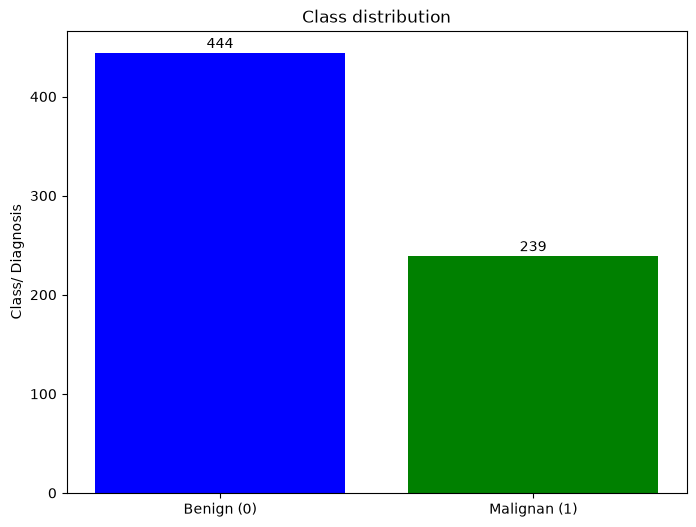

In [30]:
plt.figure(figsize=(8,6)) # usually manipulates the size
plt.bar(['Benign (0)','Malignan (1)'], counts.values, color=['blue', 'green'])
plt.title("Class distribution")
plt.ylabel('Number of samples')
plt.ylabel('Class/ Diagnosis')

for i, v in enumerate(counts.values):
    plt.text(i,v + 5, str(v), ha='center')

plt.show()

We notice that the 0 class (Benin) is more than  the 1 class (Malignant) 

splitting data

In [ ]:
X = df.drop('Diagnosis', axis = 1) # independent variable
y = df['Diagnosis'] # traget variable

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3, 
    random_state=42, 
    stratify= y # it will retain a constant proportion when splitting the two classes
)

# **Modeling**

In a DecisionTree we do not need to scale our data since the trees are scale invariant (Decision Thresholds exists)

In [37]:
n_estimators = 100 
learning_rate = 0.1 # ranges from 0.01 to 0.3
max_depth = 2

In [38]:
xgb_model = xgb.XGBClassifier(
    n_estemators = n_estimators, 
    learning_rate = learning_rate,
    max_depth = max_depth, 
    random_state=42, 
    eval_metric="logloss"
)

In [39]:
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)], 
    verbose=False
) # training the model

/home/josephridge/Documents/@software-engineering/@datascience/@emobilis/@dataScience-MAY/ML-Series/env/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [20:21:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "n_estemators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


/home/josephridge/Documents/@software-engineering/@datascience/@emobilis/@dataScience-MAY/ML-Series/env/lib/python3.13/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` instead. 
  warnings.warn(


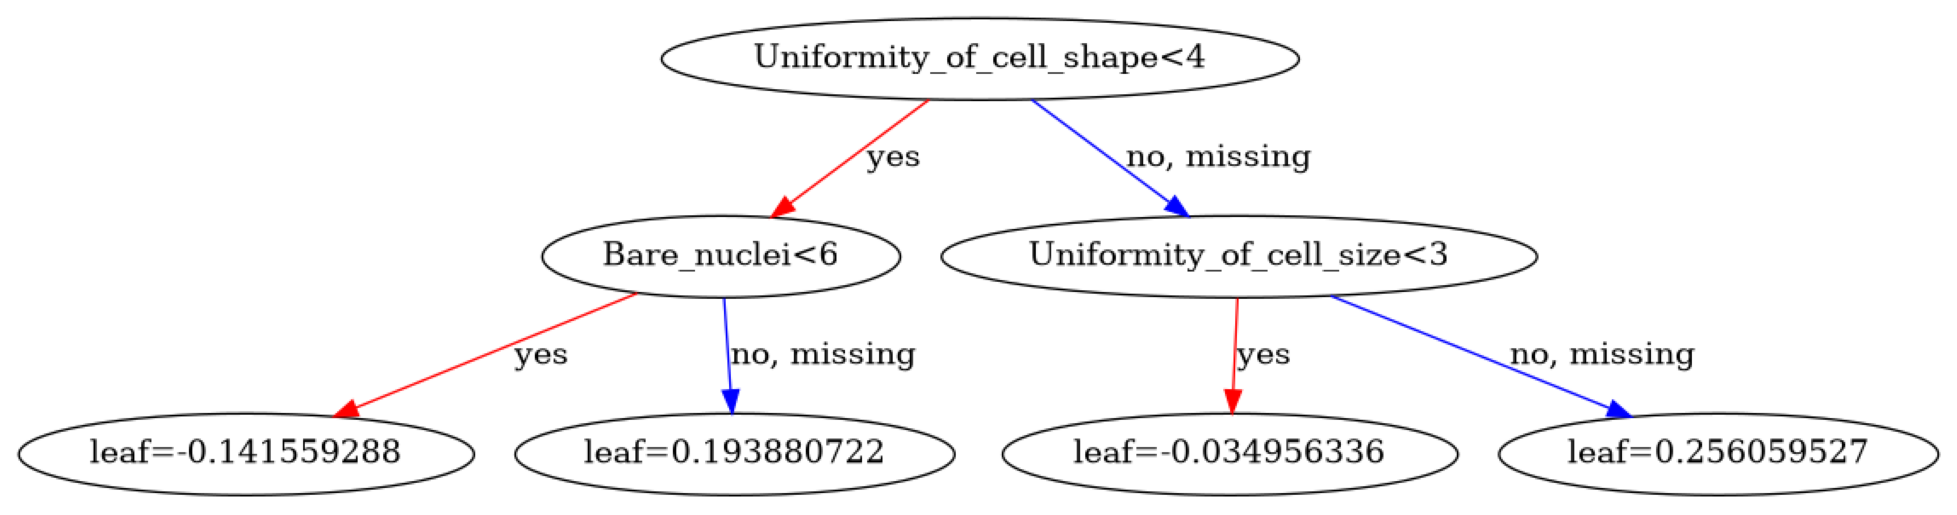

In [44]:
# plot our hm(x) decision tree
xgb.plot_tree(xgb_model, num_trees=0)
plt.rcParams['figure.figsize'] = [25,14] 
plt.show()

In [ ]:
y_pred = model.predict(X_test) # prediction
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0])

# **Evaluation**

Feature importance

In [ ]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending= False)

print("\Top 10 features: ")
print(importances.head(10))

\Top 10 features: 
Uniformity_of_cell_size        0.761703
Bare_nuclei                    0.174664
Uniformity_of_cell_shape       0.018933
Clump_thickness                0.018273
Bland_chromatin                0.014617
Single_epithelial_cell_size    0.010354
Marginal_adhesion              0.001457
ID                             0.000000
Normal_nucleoli                0.000000
Mitoses                        0.000000
dtype: float64


<>:3: SyntaxWarning: invalid escape sequence '\T'
<>:3: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_36135/2469763889.py:3: SyntaxWarning: invalid escape sequence '\T'
  print("\Top 10 features: ")


**Kindly note:**
Given the following features: Normal_nucleoli with a degree of importance at 0.000000 and Mitoses with a degree of importance at 0.000000 we need to fortify the ncessity/ degree of importance using literature (academic research)

In [ ]:
train_accuracy = accuracy_score(y_train, model.predict(X_train))
test_accuracy = accuracy_score(y_test, y_pred)

print(f" Train ACCURACY: {train_accuracy:.3f}")
print(f" Test ACCURACY: {test_accuracy:.3f}")
print(f" Tree Depth: {model.get_depth()} Leaves: {model.get_n_leaves()}")


 Train ACCURACY: 0.957
 Test ACCURACY: 0.919
 Tree Depth: 5 Leaves: 11


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.92      0.94       138
           1       0.86      0.92      0.89        72

    accuracy                           0.92       210
   macro avg       0.91      0.92      0.91       210
weighted avg       0.92      0.92      0.92       210



0 -> 2 -> Benign: 
1 -> 4 -> Malignant: 

Benign: 
- 95% were *actually* true
- 92% of the diagnosis were caught/ recalled well


Malignant: 
- 86% were *actually* true
- 92% of the diagnosis were caught/ recalled well

Accuracy of the model was at 95%

In [ ]:
print(f"confusion matrix:\n", confusion_matrix(y_test, y_pred))

confusion matrix:
 [[127  11]
 [  6  66]]


                   Benign     Malignant
actual Benign       127          11      <- 11 diagnosis were missed as benign
actual Malignant    6             66      <- 6 of benign were misclassified

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   ID                           699 non-null    int64
 1   Clump_thickness              699 non-null    int64
 2   Uniformity_of_cell_size      699 non-null    int64
 3   Uniformity_of_cell_shape     699 non-null    int64
 4   Marginal_adhesion            699 non-null    int64
 5   Single_epithelial_cell_size  699 non-null    int64
 6   Bare_nuclei                  683 non-null    str  
 7   Bland_chromatin              699 non-null    int64
 8   Normal_nucleoli              699 non-null    int64
 9   Mitoses                      699 non-null    int64
 10  Diagnosis                    699 non-null    int64
dtypes: int64(10), str(1)
memory usage: 60.2 KB


<hr>
<hr>

In [ ]:
df['Bare_nuclei'] = df['Bare_nuclei'].replace('?', pd.NA)
# # since the missing values in 'Bare_nuclei' column are less than 2% we can drop the row
df['Bare_nuclei'] = pd.to_numeric(df['Bare_nuclei']) # converts to numerical form and reassigns the column 'Bare_nulcei' 
df = df.dropna() # dropping all rows containing the  missing values 

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 683 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           683 non-null    int64  
 1   Clump_thickness              683 non-null    int64  
 2   Uniformity_of_cell_size      683 non-null    int64  
 3   Uniformity_of_cell_shape     683 non-null    int64  
 4   Marginal_adhesion            683 non-null    int64  
 5   Single_epithelial_cell_size  683 non-null    int64  
 6   Bare_nuclei                  683 non-null    float64
 7   Bland_chromatin              683 non-null    int64  
 8   Normal_nucleoli              683 non-null    int64  
 9   Mitoses                      683 non-null    int64  
 10  Diagnosis                    683 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 64.0 KB


In [ ]:
# the DecisionTreeClassifier in sklearn defaults to 'gini'
model = DecisionTreeClassifier(
    max_depth= 5, 
    min_samples_leaf=10,
    criterion='entropy', #
    random_state = 42,
)

In [ ]:
X = df.drop('Diagnosis', axis = 1)
y = df['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3, 
    random_state=42, 
    stratify= y # it will retain a constant proportion when splitting the two classes
)

In [ ]:
model.fit(X_train, y_train) # training the model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

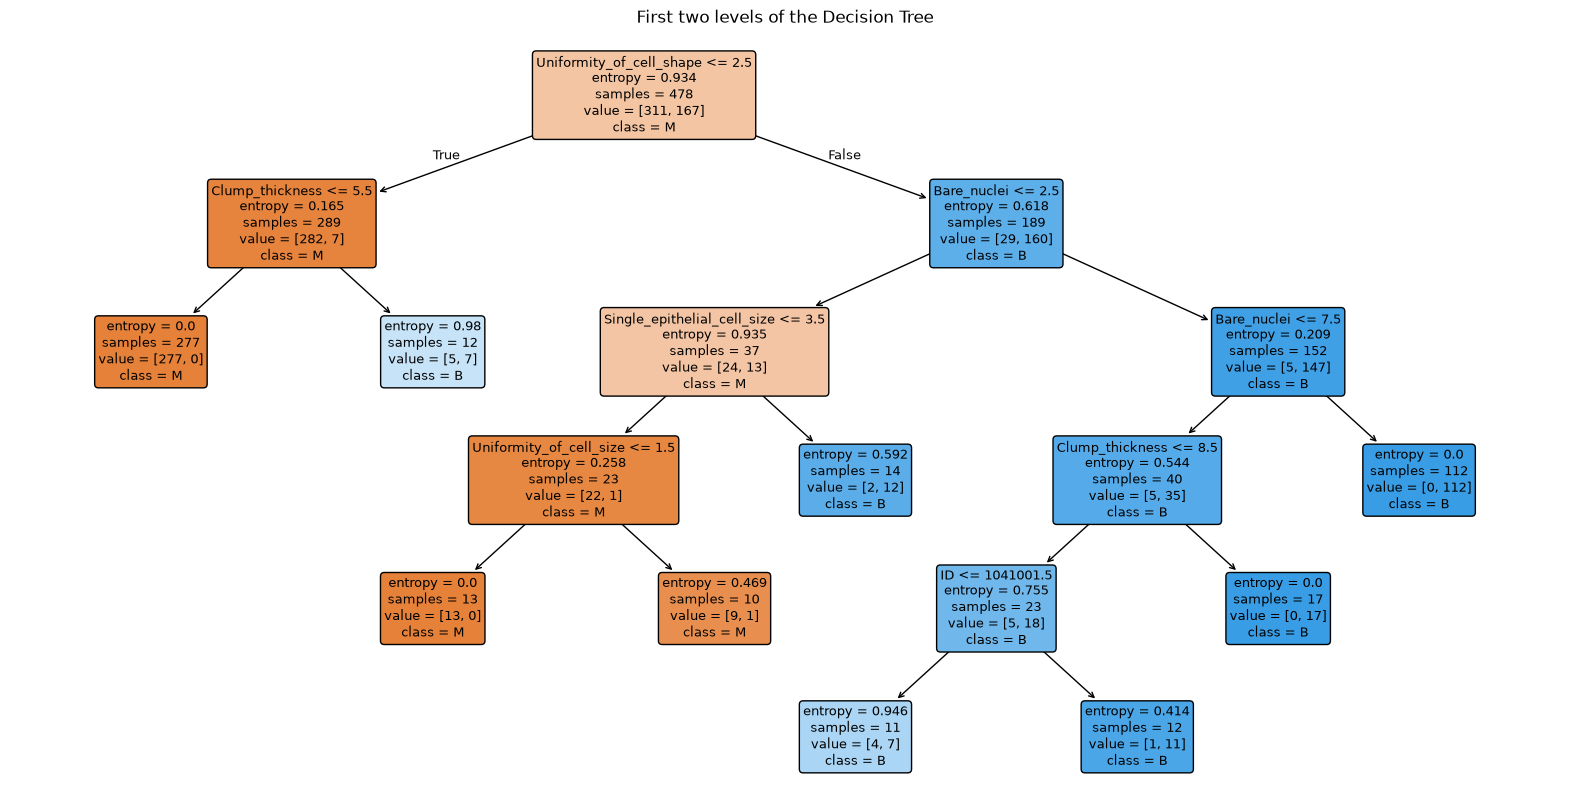

In [ ]:
# plot our tree
plt.figure(figsize=(20,10))
plot_tree(model, max_depth=5, feature_names=X.columns, class_names=['M', 'B'], filled=True , rounded=True, fontsize=9)
plt.title("First two levels of the Decision Tree")
plt.show()

In [ ]:
y_pred = model.predict(X_test) # prediction

In [ ]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending= False)

print("\Top 10 features: ")
print(importances.head(10))

\Top 10 features: 
Uniformity_of_cell_shape       0.693874
Bare_nuclei                    0.149037
Clump_thickness                0.098886
Single_epithelial_cell_size    0.050200
ID                             0.004938
Uniformity_of_cell_size        0.003064
Marginal_adhesion              0.000000
Bland_chromatin                0.000000
Normal_nucleoli                0.000000
Mitoses                        0.000000
dtype: float64


<>:3: SyntaxWarning: invalid escape sequence '\T'
<>:3: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_36135/2469763889.py:3: SyntaxWarning: invalid escape sequence '\T'
  print("\Top 10 features: ")


In [ ]:
train_accuracy = accuracy_score(y_train, model.predict(X_train))
test_accuracy = accuracy_score(y_test, y_pred)

print(f" Train ACCURACY: {train_accuracy:.3f}")
print(f" Test ACCURACY: {test_accuracy:.3f}")
print(f" Tree Depth: {model.get_depth()} Leaves: {model.get_n_leaves()}")


 Train ACCURACY: 0.973
 Test ACCURACY: 0.937
 Tree Depth: 5 Leaves: 9


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.92      0.95       133
           1       0.86      0.97      0.92        72

    accuracy                           0.94       205
   macro avg       0.92      0.94      0.93       205
weighted avg       0.94      0.94      0.94       205



RMSE
MSE
MAE
R_2
precision
recall
f1-score

In [ ]:
print(f"confusion matrix:\n", confusion_matrix(y_test, y_pred))

confusion matrix:
 [[122  11]
 [  2  70]]
